In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf
import scarf.plotting as splt
from scarf.embeddings import initial_embedding

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
baseline = ds.pipeline.open(label="docs_default")
cell_selection = baseline["analysis_cell_selection"]
hvg_ref = baseline["highly_variable_features"]
run_cells = baseline.cells

In [2]:
normalized = ds.run_normalization(cell_selection, hvg_ref)
pca = ds.run_pca(normalized, dims=15)
initialization = ds.build_embedding_initialization(pca)
ann_index = ds.build_ann_index(pca)
neighbors = ds.query_neighbors(ann_index, k=11)
graph = ds.build_connectivity_map(neighbors)
graph

ArtifactRef(assay='RNA', kind='connectivity_map', artifact_id='d9a2230415db...')

In [3]:
stage_rows = []
for name, ref in (
    ("normalized", normalized),
    ("pca", pca),
    ("initialization", initialization),
    ("ann_index", ann_index),
    ("neighbors", neighbors),
    ("graph", graph),
):
    status = ds.inspect_artifact(ref)
    stage_rows.append(
        {
            "stage": name,
            "operation": status.operation,
            "complete": status.complete,
        }
    )
pd.DataFrame(stage_rows)

,stage,operation,complete
0,normalized,run_normalization,True
1,pca,run_pca,True
2,initialization,build_embedding_initialization,True
3,ann_index,build_ann_index,True
4,neighbors,query_neighbors,True
5,graph,build_connectivity_map,True


In [4]:
loaded_graph = ds.load_graph(graph)
loaded_graph.shape, loaded_graph.nnz

((3940, 3940), 43340)

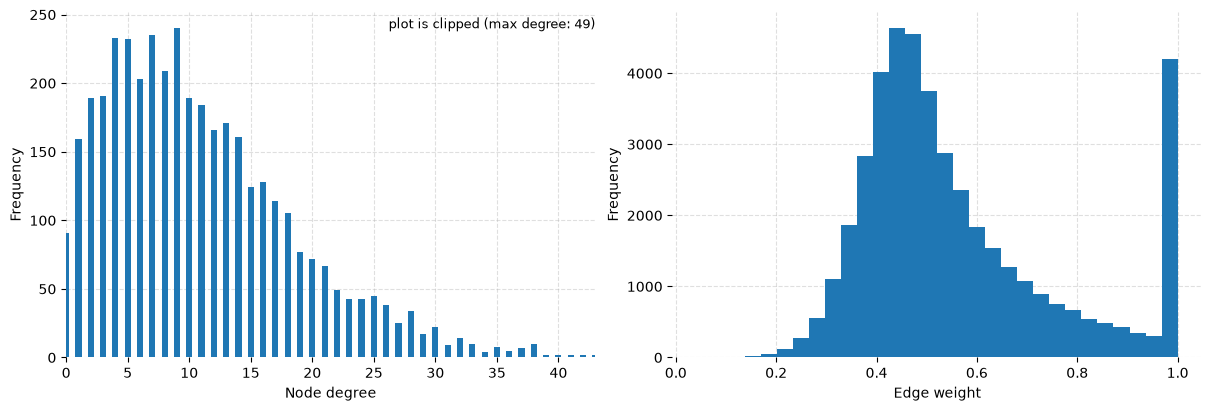

In [5]:
splt.graph_qc(loaded_graph)

In [6]:
degrees = np.asarray((loaded_graph != 0).sum(axis=0)).ravel()
pd.Series(
    {
        "active cells": int(loaded_graph.shape[0]),
        "isolated cells": int((degrees == 0).sum()),
        "median degree": float(np.median(degrees)),
        "min degree": int(degrees.min()),
        "max degree": int(degrees.max()),
    },
    name="graph coverage",
)

active cells      3940.0
isolated cells      91.0
median degree        9.0
min degree           0.0
max degree          49.0
Name: graph coverage, dtype: float64

In [7]:
degree_vs_qc = pd.DataFrame(
    {
        "degree": degrees,
        "RNA_nCounts": run_cells.fetch("RNA_nCounts"),
        "RNA_nFeatures": run_cells.fetch("RNA_nFeatures"),
    }
)
degree_vs_qc.corr(numeric_only=True)

,degree,RNA_nCounts,RNA_nFeatures
degree,1.000000,0.091962,0.066012
RNA_nCounts,0.091962,1.000000,0.876832
RNA_nFeatures,0.066012,0.876832,1.000000


In [8]:
{
    "cell selection": cell_selection,
    "feature selection": hvg_ref,
    "normalization": normalized,
    "reduction": pca,
    "embedding initialization": initialization,
    "neighbours": neighbors,
    "connectivity": graph,
}

{'cell selection': ArtifactRef(datastore, kind='cell_selection', artifact_id='a4137c5ada6d...'),
 'feature selection': ArtifactRef(assay='RNA', kind='feature_selection', artifact_id='adeede36cdca...'),
 'normalization': ArtifactRef(assay='RNA', kind='normalized', artifact_id='24cfc31e5c04...'),
 'reduction': ArtifactRef(assay='RNA', kind='reduction', artifact_id='9f870f98ef66...'),
 'embedding initialization': ArtifactRef(assay='RNA', kind='embedding_initialization', artifact_id='ad4e5f8e31fb...'),
 'neighbours': ArtifactRef(assay='RNA', kind='neighbors', artifact_id='ff42aae647b3...'),
 'connectivity': ArtifactRef(assay='RNA', kind='connectivity_map', artifact_id='d9a2230415db...')}

In [9]:
init_status = ds.inspect_artifact(initialization)
init_group = ds.load_artifact(initialization)
centers = np.asarray(init_group["cluster_centers"][:])
labels = np.asarray(init_group["cluster_labels"][:])
{
    "operation": init_status.operation,
    "n_centroids": init_status.parameters.get("n_centroids"),
    "cluster_centers": centers.shape,
    "n_labels": int(pd.Series(labels).nunique()),
    "complete": init_status.complete,
}

{'operation': 'build_embedding_initialization',
 'n_centroids': 1000,
 'cluster_centers': (1000, 15),
 'n_labels': 997,
 'complete': True}

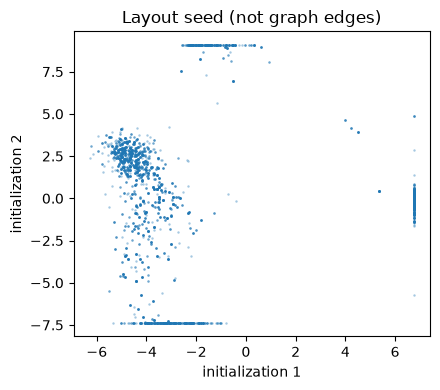

In [10]:
ini_coords = initial_embedding(centers, labels, 2)
figure, axis = plt.subplots(figsize=(4.5, 4))
axis.scatter(ini_coords[:, 0], ini_coords[:, 1], s=3, alpha=0.4, linewidths=0)
axis.set_xlabel("initialization 1")
axis.set_ylabel("initialization 2")
axis.set_title("Layout seed (not graph edges)")
figure.tight_layout()
figure

In [11]:
umap = ds.run_umap(graph, initialization)
clusters = ds.run_leiden_clustering(graph, resolution=0.5)
umap_values = np.asarray(ds.load_artifact(umap)["values"][:])
cluster_values = np.asarray(ds.load_artifact(clusters)["values"][:])
plt.scatter(umap_values[:, 0], umap_values[:, 1], c=cluster_values, s=3)

In [12]:
ds.inspect_artifact(clusters).parameters

{'resolution': 0.5,
 'backend': 'igraph',
 'symmetric_graph': False,
 'graph_upper_only': False,
 'random_seed': 4444}

In [13]:
neighbors_k21 = ds.query_neighbors(ann_index, k=21)
graph_k21 = ds.build_connectivity_map(neighbors_k21)
graph_k21 != graph

True

In [14]:
loaded_graph_k21 = ds.load_graph(graph_k21)
pd.Series(
    {
        "k=11 nnz": int(loaded_graph.nnz),
        "k=21 nnz": int(loaded_graph_k21.nnz),
    },
    name="edges",
)

k=11 nnz    43340
k=21 nnz    82740
Name: edges, dtype: int64

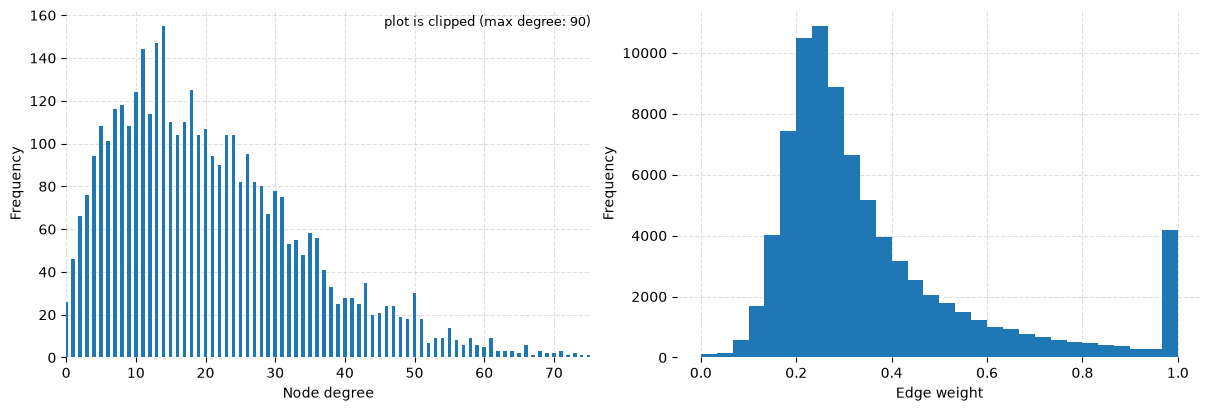

In [15]:
splt.graph_qc(loaded_graph_k21)

In [16]:
clusters_k21 = ds.run_leiden_clustering(graph_k21, resolution=0.5)

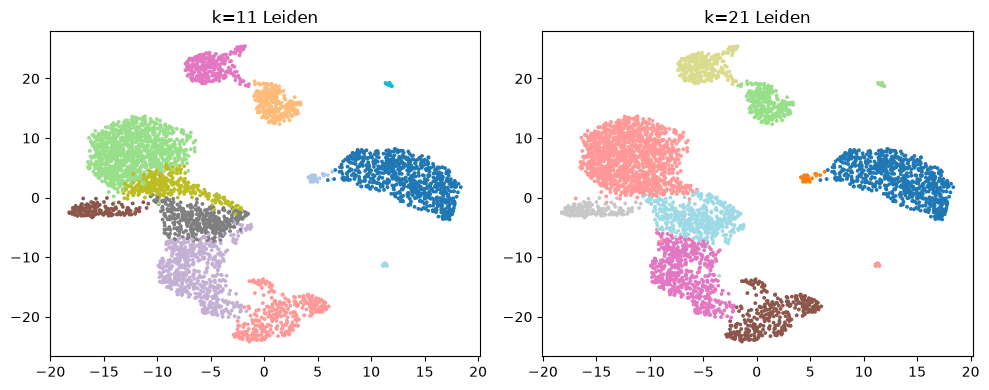

In [17]:
cluster_values_k21 = np.asarray(ds.load_artifact(clusters_k21)["values"][:])
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, values, title in zip(
    axes,
    (cluster_values, cluster_values_k21),
    ("k=11 Leiden", "k=21 Leiden"),
    strict=True,
):
    axis.scatter(
        umap_values[:, 0],
        umap_values[:, 1],
        c=values,
        s=3,
        cmap="tab20",
    )
    axis.set_title(title)
figure.tight_layout()
figure

In [18]:
pd.crosstab(
    pd.Series(cluster_values, name="k=11"),
    pd.Series(cluster_values_k21, name="k=21"),
)

k=21,1,2,3,4,5,6,7,8,9
k=11,,,,,,,,,
1,694,0,0,0,0,0,0,0,0
2,0,28,0,0,0,0,0,0,0
3,0,0,237,0,0,0,0,0,0
4,0,0,0,1002,0,0,0,0,2
5,0,0,0,0,317,0,0,0,0
6,0,0,0,1,1,501,0,0,36
7,0,0,0,1,0,0,141,0,0
8,0,0,4,0,0,0,0,259,0
9,0,0,0,2,0,17,0,0,359
